In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout

# Load data
df = pd.read_csv("logs.csv")
texts = df["normalized_message"].fillna("").astype(str).tolist()
labels = df["is_fault"].astype(int).values

# Tokenize text
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

# Pad to fixed length
X = pad_sequences(sequences, maxlen=50)  # adjust maxlen based on log length
y = np.array(labels)


In [2]:
def build_lstm_model(vocab_size, max_len):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
    model.add(LSTM(128, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))  # Binary classification
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

vocab_size = len(tokenizer.word_index) + 1
max_len = X.shape[1]
lstm_model = build_lstm_model(vocab_size, max_len)

# Train
history = lstm_model.fit(X, y, epochs=5, batch_size=32, validation_split=0.2)


Epoch 1/5


C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


640/640 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9627 - loss: 0.0909 - val_accuracy: 0.9877 - val_loss: 0.0113
Epoch 2/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9998 - loss: 7.1568e-04 - val_accuracy: 0.9885 - val_loss: 0.0492
Epoch 3/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 1.0000 - loss: 5.0151e-05 - val_accuracy: 0.9885 - val_loss: 0.0254
Epoch 4/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 1.0000 - loss: 1.3497e-05 - val_accuracy: 0.9883 - val_loss: 0.0436
Epoch 5/5
640/640 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 1.0000 - loss: 1.6269e-06 - val_accuracy: 0.9885 - val_loss: 0.0494


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error, mean_absolute_error
import numpy as np

# Train/test split (time-agnostic, you can also do TimeSeriesSplit if you want order preserved)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# Build LSTM model
lstm_model = build_lstm_model(vocab_size, max_len)

# Train
history = lstm_model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=1)

# Predict
y_pred_probs = lstm_model.predict(X_test).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)


Epoch 1/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9675 - loss: 0.1001 - val_accuracy: 1.0000 - val_loss: 2.7301e-04
Epoch 2/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9999 - loss: 8.7698e-04 - val_accuracy: 1.0000 - val_loss: 8.6003e-05
Epoch 3/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 6.5784e-05
Epoch 4/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 1.0000 - loss: 3.6116e-05 - val_accuracy: 1.0000 - val_loss: 9.6877e-06
Epoch 5/5
576/576 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 1.0000 - loss: 8.7337e-06 - val_accuracy: 1.0000 - val_loss: 4.8864e-06
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [4]:
# Classification metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_probs)

# Regression-style error (on probabilities)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_probs))
mae = mean_absolute_error(y_test, y_pred_probs)

print("🔹 LSTM Evaluation on Test Set")
print("Accuracy:", acc)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)
print("RMSE:", rmse)
print("MAE:", mae)


🔹 LSTM Evaluation on Test Set
Accuracy: 1.0
F1 Score: 1.0
ROC-AUC: 1.0
RMSE: 5.169884164430796e-05
MAE: 2.6616219201969216e-06


In [5]:
scores = lstm_model.predict(X).flatten()

from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(scores, order=(2,1,2))
fitted = model.fit()
forecast_scores = fitted.forecast(steps=10)
print("Forecasted next 10 scores:", forecast_scores)


799/799 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
Forecasted next 10 scores: [0.76655745 0.47231593 0.7624599  0.49068574 0.7457042  0.50642334
 0.73093829 0.52027808 0.71793852 0.53247564]


In [6]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# --- Step 1: Load and vectorize logs ---
df = pd.read_csv("logs.csv")
df["normalized_message"] = df["normalized_message"].fillna("").astype(str)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df["normalized_message"]).toarray()
y = df["is_fault"].values

# Reshape for LSTM (samples, timesteps=1, features)
X = np.expand_dims(X, axis=1)

# --- Step 2: TimeSeriesSplit ---
tscv = TimeSeriesSplit(n_splits=5)

fold = 1
for train_idx, test_idx in tscv.split(X):
    print(f"\n🔹 Fold {fold}")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- Step 3: Build LSTM ---
    model = Sequential([
        LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    # --- Step 4: Train ---
    model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

    # --- Step 5: Evaluate ---
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_prob))
    mae = mean_absolute_error(y_test, y_pred_prob)

    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")

    fold += 1



🔹 Fold 1


C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.9911
F1 Score: 0.9846
ROC-AUC: 0.9994
RMSE: 0.0993
MAE: 0.0230

🔹 Fold 2


C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.9352
F1 Score: 0.9652
ROC-AUC: 0.9820
RMSE: 0.2468
MAE: 0.0700

🔹 Fold 3


...

134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 1.0000
F1 Score: 1.0000
ROC-AUC: 1.0000
RMSE: 0.0172
MAE: 0.0040

🔹 Fold 4


C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.9986
F1 Score: 0.9992
ROC-AUC: 1.0000
RMSE: 0.0278
MAE: 0.0017

🔹 Fold 5


C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 1.0000
F1 Score: 1.0000
ROC-AUC: 1.0000
RMSE: 0.0070
MAE: 0.0013


In [9]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error, mean_absolute_error
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

# Function to build GRU model
def build_gru_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(64),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Cross-validation with GRU
tscv = TimeSeriesSplit(n_splits=5)
fold = 1
metrics = {"acc": [], "f1": [], "roc": [], "rmse": [], "mae": []}

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]   # <-- fixed

    model = build_gru_model((X_train.shape[1], X_train.shape[2]))
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred_prob)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_prob))
    mae = mean_absolute_error(y_test, y_pred_prob)

    print(f"\n🔹 Fold {fold}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")

    fold += 1


# Summary across folds
print("\n📊 GRU Cross-Validation Summary")
for k, v in metrics.items():
    print(f"{k.upper()}: {np.mean(v):.4f} ± {np.std(v):.4f}")


134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

🔹 Fold 1
Accuracy: 0.9911
F1 Score: 0.9846
ROC-AUC: 0.9996
RMSE: 0.0093
MAE: 0.0143
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

🔹 Fold 2
Accuracy: 0.9355
F1 Score: 0.9653
ROC-AUC: 0.9820
RMSE: 0.0629
MAE: 0.0662
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

🔹 Fold 3
Accuracy: 1.0000
F1 Score: 1.0000
ROC-AUC: 1.0000
RMSE: 0.0000
MAE: 0.0012
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

🔹 Fold 4
Accuracy: 0.9995
F1 Score: 0.9997
ROC-AUC: 1.0000
RMSE: 0.0005
MAE: 0.0010
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

🔹 Fold 5
Accuracy: 1.0000
F1 Score: 1.0000
ROC-AUC: 1.0000
RMSE: 0.0000
MAE: 0.0002

📊 GRU Cross-Validation Summary
ACC: nan ± nan
F1: nan ± nan
ROC: nan ± nan
RMSE: nan ± nan
MAE: nan ± nan


C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [11]:
import numpy as np

def predict_next_logs(model, last_logs, steps=10):
    predictions = []
    input_seq = last_logs.copy().reshape(1, last_logs.shape[0], last_logs.shape[1])  

    for _ in range(steps):
        # Predict next step
        pred = model.predict(input_seq, verbose=0)
        pred_label = int((pred > 0.5).astype(int))   # threshold at 0.5 for classification
        predictions.append(pred_label)

        # Append new prediction and slide window
        new_step = np.zeros((1, last_logs.shape[1]))
        new_step[0, 0] = pred_label   # assuming is_fault is the first column

        input_seq = np.append(input_seq[:, 1:, :], new_step.reshape(1,1,-1), axis=1)

    return predictions


In [20]:
# Suppose X_train is your data, shaped (samples, timesteps, features)
last_10_logs = X_train[-10]   # get last 10 timesteps
preds = predict_next_logs(model, last_10_logs, steps=10)

print("Predicted next 10 is_fault logs:", preds)


C:\Users\PKM\AppData\Local\Temp\ipykernel_15748\543601175.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = int((pred > 0.5).astype(int))   # threshold at 0.5 for classification


Predicted next 10 is_fault logs: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


ValueError: Exception encountered when calling GRUCell.call().

[1mDimensions must be equal, but are 1 and 5000 for '{{node sequential_12_1/gru_5_1/gru_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_12_1/gru_5_1/strided_slice_1, sequential_12_1/gru_5_1/gru_cell_1/Cast/ReadVariableOp)' with input shapes: [1,1], [5000,192].[0m

Arguments received by GRUCell.call():
  • inputs=tf.Tensor(shape=(1, 1), dtype=float32)
  • states=('tf.Tensor(shape=(1, 64), dtype=float32)',)
  • training=False

ValueError: Exception encountered when calling GRUCell.call().

[1mDimensions must be equal, but are 1 and 5000 for '{{node sequential_12_1/gru_5_1/gru_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_12_1/gru_5_1/strided_slice_1, sequential_12_1/gru_5_1/gru_cell_1/Cast/ReadVariableOp)' with input shapes: [1,1], [5000,192].[0m

Arguments received by GRUCell.call():
  • inputs=tf.Tensor(shape=(1, 1), dtype=float32)
  • states=('tf.Tensor(shape=(1, 64), dtype=float32)',)
  • training=False

In [6]:
"""
Improved LSTM inference & tokenizer pipeline

What's new vs previous file:
- Better tokenizer options:
  1. Keras TextVectorization with n-grams and subword-level tokenization (via `split` + ngrams). Fast when adapted and serializable.
  2. Hashing + n-gram hashing + Embedding for constant-time, minimal-setup tokenization (very low latency).
  3. TF-IDF TextVectorization (output_mode='tf_idf') + a fast scikit-learn classifier (LogisticRegression or LightGBM) as an ultra-fast production alternative to LSTM.
- Improved model: Bidirectional LSTM with attention-lite (self-attention via simple dense gating) and more regularization.
- Auto-benchmark utilities to compare tokenization + model inference latency and choose the best for realtime.
- A compact `select_runtime_pipeline` helper to pick "high-accuracy" (LSTM + TextVectorization) or "low-latency" (Hashing + Embedding) or "fast-linear" (TF-IDF + LR) at deployment time.

How to use:
- For best accuracy: train TextVectorization + BiLSTM model (recommended for offline training). Save the model and load in production.
- For lowest latency: train the hashing model and use it in realtime (no adapt step; deterministic runtime cost).
- For minimal CPU & very fast inference at scale: use TF-IDF + LogisticRegression (serialize with joblib).

Notes about perfect metrics:
- If you saw perfect 1.0 metrics earlier, there is likely data leakage. Always split by time (if logs are time-series) or by unique sessions so training and test are strictly separated.

Requirements:
- tensorflow>=2.10, scikit-learn, numpy, pandas, joblib, lightgbm (optional)

"""

from typing import List, Dict, Optional, Tuple
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM, Dense,
                                     Dropout, LayerNormalization, Input)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras import backend as K

from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import HashingVectorizer, TfidfVectorizer
import joblib

# ---------- CONFIG ----------
VOCAB_SIZE = 25000
MAX_LEN = 64
EMBED_DIM = 128
BATCH_SIZE = 128
EPOCHS = 10
MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)


# ---------- Utility: simple attention-like gating (lightweight) ----------
from tensorflow.keras.layers import Layer

class SimpleSelfAttention(Layer):
    """Lightweight attention: computes a weighted sum of features using learned gating."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], 1), initializer="glorot_uniform", trainable=True)
        super().build(input_shape)
    def call(self, x):
        # x: (batch, features)
        scores = tf.matmul(x, self.w)  # (batch, 1)
        weights = tf.nn.softmax(scores, axis=0)
        return x * weights


# ---------- Model builders ----------
def build_bilstm_with_textvectorization(vocab_size: int = VOCAB_SIZE,
                                       max_len: int = MAX_LEN,
                                       embed_dim: int = EMBED_DIM,
                                       ngrams: Optional[int] = None) -> tf.keras.Model:
    """
    Builds a model that includes TextVectorization (string input) so you can save a single artifact.
    Use `vectorize_layer.adapt(texts)` before training.
    """
    vectorize = TextVectorization(max_tokens=vocab_size,
                                  output_mode="int",
                                  output_sequence_length=max_len,
                                  name="text_vectorization",
                                  ngrams=ngrams)

    inputs = Input(shape=(1,), dtype=tf.string, name="log_input")
    x = vectorize(inputs)  # integer sequences
    x = Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len, name="embed")(x)
    x = Bidirectional(LSTM(128, return_sequences=False), name="bilstm")(x)
    x = LayerNormalization()(x)
    # small attention/gating
    x = Dense(128, activation="tanh")(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="bilstm_textvec_model")
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model


def build_bilstm_with_hashing(num_bins: int = 20000,
                            max_len: int = MAX_LEN,
                            embed_dim: int = EMBED_DIM,
                            ngram_range: Tuple[int,int] = (1,2)) -> tf.keras.Model:
    """
    Hashing tokenizer: splits on whitespace, builds 1..2 grams, hashes to num_bins via tf.strings.to_hash_bucket_fast.
    This requires no adaptation and is deterministic and fast at runtime.
    """
    inputs = Input(shape=(1,), dtype=tf.string, name="log_input")

    def split_and_hash(x):
        # x is shape (batch, 1) strings
        x = tf.reshape(x, [-1])
        tokens = tf.strings.split(x)  # ragged
        # generate simple ngrams (1 and 2)
        def make_ngrams(tokens_row):
            parts = tokens_row.to_list()
            out = []
            for i in range(len(parts)):
                out.append(parts[i])
                if i + 1 < len(parts):
                    out.append(parts[i] + "_" + parts[i+1])
            return out

        # Vectorize via tf.py_function for simple ngrams -> hashed ints
        def py_hash(rows):
            out_rows = []
            for r in rows:
                toks = str(r).split()
                ngrams = []
                for i in range(len(toks)):
                    ngrams.append(toks[i])
                    if i+1 < len(toks):
                        ngrams.append(toks[i] + "_" + toks[i+1])
                # truncate/pad to max_len
                ngrams = ngrams[:max_len]
                out_rows.append(ngrams)
            return np.array(out_rows, dtype=object)

        toks = tf.py_function(func=py_hash, inp=[x], Tout=tf.dtypes.string)
        toks = toks.to_tensor(default_value=b"")  # (batch, <=max_len)
        toks = tf.strings.substr(toks, 0, 200)
        hashed = tf.strings.to_hash_bucket_fast(toks, num_bins)
        return hashed

    x = tf.keras.layers.Lambda(split_and_hash, output_shape=(max_len,), name="hash_tokenizer")(inputs)
    x = Embedding(input_dim=num_bins, output_dim=embed_dim, input_length=max_len)(x)
    x = Bidirectional(LSTM(128, return_sequences=False))(x)
    x = LayerNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="bilstm_hash_model")
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model


# ---------- Fast linear alternative: TF-IDF + Logistic Regression ----------
class FastLinearText:
    """
    Provides fit/predict using TF-IDF (or HashingVectorizer) + LogisticRegression. Extremely fast at inference.
    Save model with joblib.
    """
    def __init__(self, use_hashing: bool = False, n_features: int = 20000, ngram_range=(1,2)):
        self.use_hashing = use_hashing
        if use_hashing:
            self.vec = HashingVectorizer(n_features=n_features, ngram_range=ngram_range, alternate_sign=False)
        else:
            self.vec = TfidfVectorizer(max_features=n_features, ngram_range=ngram_range)
        self.clf = LogisticRegression(max_iter=1000)

    def fit(self, texts: List[str], labels: np.ndarray):
        X = self.vec.fit_transform(texts) if not self.use_hashing else self.vec.transform(texts)
        self.clf.fit(X, labels)
        return self

    def predict_proba(self, texts: List[str]) -> np.ndarray:
        X = self.vec.transform(texts)
        return self.clf.predict_proba(X)[:, 1]

    def save(self, path: str):
        joblib.dump({"vec": self.vec, "clf": self.clf}, path)

    @staticmethod
    def load(path: str):
        d = joblib.load(path)
        obj = FastLinearText()
        obj.vec = d["vec"]
        obj.clf = d["clf"]
        return obj


# ---------- Training helpers ----------

def train_textvec_lstm(df: pd.DataFrame, text_col: str = "normalized_message", label_col: str = "is_fault",
                       ngrams: Optional[int] = 2, model_path: Optional[str] = None, val_size: float = 0.15):
    df[text_col] = df[text_col].fillna("").astype(str)
    texts = df[text_col].values
    labels = df[label_col].astype(int).values

    # prefer time-based split if there is a timestamp column; otherwise stratify
    X_train, X_val, y_train, y_val = train_test_split(texts, labels, test_size=val_size, stratify=labels, random_state=42)

    model = build_bilstm_with_textvectorization(ngrams=ngrams)
    vectorize_layer = model.get_layer("text_vectorization")
    vectorize_layer.adapt(X_train)

    classes = np.unique(y_train)
    cw = class_weight.compute_class_weight("balanced", classes=classes, y=y_train)
    cw_dict = {int(c): float(w) for c, w in zip(classes, cw)}

    if model_path is None:
        model_path = os.path.join(MODEL_DIR, "bilstm_textvec_saved")

    checkpoint_path = model_path + "_best.h5"
    callbacks = [EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
                 ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True)]

    model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=BATCH_SIZE, epochs=EPOCHS,
              class_weight=cw_dict, callbacks=callbacks, verbose=2)

    preds = model.predict(X_val, batch_size=512).ravel()
    pred_labels = (preds >= 0.5).astype(int)
    print("Val Accuracy:", accuracy_score(y_val, pred_labels))
    print("Val F1:", f1_score(y_val, pred_labels))
    try:
        print("Val ROC-AUC:", roc_auc_score(y_val, preds))
    except Exception:
        pass

    model.save(model_path, include_optimizer=False)
    print(f"Saved model to {model_path}")
    return model_path


def train_hashing_lstm(df: pd.DataFrame, text_col: str = "normalized_message", label_col: str = "is_fault",
                       model_path: Optional[str] = None):
    df[text_col] = df[text_col].fillna("").astype(str)
    texts = df[text_col].values
    labels = df[label_col].astype(int).values

    X_train, X_val, y_train, y_val = train_test_split(texts, labels, test_size=0.15, stratify=labels, random_state=42)

    model = build_bilstm_with_hashing()

    checkpoint_path = (model_path or os.path.join(MODEL_DIR, "bilstm_hash_saved")) + "_best.h5"
    callbacks = [EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
                 ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True)]

    model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=BATCH_SIZE, epochs=EPOCHS,
              callbacks=callbacks, verbose=2)

    preds = model.predict(X_val, batch_size=512).ravel()
    print("Val Acc:", accuracy_score(y_val, (preds>=0.5).astype(int)))
    model.save(model_path or os.path.join(MODEL_DIR, "bilstm_hash_saved"), include_optimizer=False)
    return model_path or os.path.join(MODEL_DIR, "bilstm_hash_saved")


def train_fast_linear(df: pd.DataFrame, text_col: str = "normalized_message", label_col: str = "is_fault",
                      use_hashing: bool = False, save_path: Optional[str] = None):
    texts = df[text_col].fillna("").astype(str).tolist()
    labels = df[label_col].astype(int).values

    X_train, X_val, y_train, y_val = train_test_split(texts, labels, test_size=0.15, stratify=labels, random_state=42)
    fl = FastLinearText(use_hashing=use_hashing)
    fl.fit(X_train, y_train)
    probs = fl.predict_proba(X_val)
    print("Val Acc:", accuracy_score(y_val, (probs>=0.5).astype(int)))
    if save_path is None:
        save_path = os.path.join(MODEL_DIR, "fast_linear.joblib")
    fl.save(save_path)
    print(f"Saved fast linear model to {save_path}")
    return save_path


# ---------- Inference utilities ----------

def load_tf_model(model_path: str) -> tf.keras.Model:
    model = load_model(model_path)
    return model


def load_fast_linear(path: str) -> FastLinearText:
    return FastLinearText.load(path)


def predict_batch_tf(model: tf.keras.Model, texts: List[str], threshold: float = 0.5) -> List[Dict]:
    arr = np.array(texts, dtype=object).reshape(-1, 1)
    start = time.time()
    probs = model.predict(arr, batch_size=64).ravel()
    latency = (time.time() - start) / len(texts)
    return [{"log": t, "prob": float(p), "is_fault": int(p>=threshold)} for t, p in zip(texts, probs)], latency


def predict_batch_fast_linear(fl: FastLinearText, texts: List[str], threshold: float = 0.5):
    start = time.time()
    probs = fl.predict_proba(texts)
    latency = (time.time() - start) / len(texts)
    return [{"log": t, "prob": float(p), "is_fault": int(p>=threshold)} for t, p in zip(texts, probs)], latency


# ---------- Auto-select runtime pipeline ----------

def select_runtime_pipeline(preferred: str = "auto"):
    """Choose between: 'high-accuracy', 'low-latency', 'fast-linear' or 'auto'.
    'auto' picks low-latency when CPU budget is small.
    """
    if preferred == "high-accuracy":
        return {"type": "tf_lstm_textvec", "model_path": os.path.join(MODEL_DIR, "bilstm_textvec_saved")}
    if preferred == "low-latency":
        return {"type": "tf_lstm_hash", "model_path": os.path.join(MODEL_DIR, "bilstm_hash_saved")}
    if preferred == "fast-linear":
        return {"type": "fast_linear", "model_path": os.path.join(MODEL_DIR, "fast_linear.joblib")}
    # auto: choose fast-linear for CPU-limited environments
    return {"type": "fast_linear", "model_path": os.path.join(MODEL_DIR, "fast_linear.joblib")}


# ---------- Example quick-run (train small, compare pipelines) ----------
if __name__ == "__main__":
    data_path = "logs.csv"
    if Path(data_path).exists():
        df = pd.read_csv(data_path)

        print("--- Training fast linear (TF-IDF + LR) ---")
        fl_path = train_fast_linear(df)

        print("--- Training TextVectorization + BiLSTM (high-accuracy) ---")
        tv_model_path = train_textvec_lstm(df)

        print("--- Training Hashing LSTM (low-latency) ---")
        hash_model_path = train_hashing_lstm(df)

        # quick inference comparison on 10 sample logs
        sample_logs = df["normalized_message"].fillna("").astype(str).head(10).tolist()

        # fast linear
        fl = FastLinearText.load(fl_path)
        out, lat = predict_batch_fast_linear(fl, sample_logs)
        print("Fast-linear latency per-log:", lat)

        # textvec LSTM
        m = load_tf_model(tv_model_path)
        out2, lat2 = predict_batch_tf(m, sample_logs)
        print("TextVec LSTM latency per-log:", lat2)

        # hashing LSTM
        mh = load_tf_model(hash_model_path)
        out3, lat3 = predict_batch_tf(mh, sample_logs)
        print("Hash LSTM latency per-log:", lat3)

        print("Done. Choose pipeline with select_runtime_pipeline().")
    else:
        print("Put logs.csv next to this script and run to train all pipelines. Use select_runtime_pipeline() to pick one.")


--- Training fast linear (TF-IDF + LR) ---
Val Acc: 0.9994786235662148
Saved fast linear model to saved_models\fast_linear.joblib
--- Training TextVectorization + BiLSTM (high-accuracy) ---


C:\Users\PKM\anaconda3\envs\venv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


ValueError: The filepath provided must end in `.keras` (Keras model format). Received: filepath=saved_models\bilstm_textvec_saved_best.h5

In [7]:
import os
cw = class_weight.compute_class_weight("balanced", classes=classes, y=y_train)
cw_dict = {int(c): float(w) for c, w in zip(classes, cw)}


# Callbacks
checkpoint_path = save_model_path.replace('.keras', '_best.keras')
callbacks = [
EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)
]


# Train
model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=BATCH_SIZE, epochs=EPOCHS,
class_weight=cw_dict, callbacks=callbacks, verbose=2)


# Evaluate on validation
preds = model.predict(X_val, batch_size=512).ravel()
pred_labels = (preds >= 0.5).astype(int)
print("Val Acc:", accuracy_score(y_val, pred_labels))
print("Val F1:", f1_score(y_val, pred_labels))
try:
print("Val ROC-AUC:", roc_auc_score(y_val, preds))
except Exception:
pass


# Save final model (Keras format)
model.save(save_model_path, include_optimizer=False)
print(f"Saved Keras model to {save_model_path}")


# Save a small manifest via joblib for inference to load
manifest = {
"model_path": save_model_path,
"threshold": 0.5,
"vocab_size": VOCAB_SIZE,
"max_len": MAX_LEN
}
joblib.dump(manifest, manifest_path)
print(f"Saved manifest to {manifest_path}")
return save_model_path, manifest_path


# ---------------- Run from CLI ----------------
if __name__ == '__main__':
import argparse
parser = argparse.ArgumentParser()
parser.add_argument('--csv', type=str, default='logs.csv', help='Path to logs.csv')
parser.add_argument('--save', type=str, default=MODEL_PATH, help='Where to save .keras model')
parser.add_argument('--manifest', type=str, default=MANIFEST_PATH, help='Where to save manifest joblib')
args = parser.parse_args()


if not Path(args.csv).exists():
raise SystemExit(f"CSV not found at {args.csv}. Put logs.csv next to this script or pass --csv path")


train_from_csv(args.csv, save_model_path=args.save, manifest_path=args.manifest)

IndentationError: expected an indented block after 'try' statement on line 24 (3736196991.py, line 25)

In [8]:
# inference_lstm_textvec.py
"""
Inference script for realtime LSTM + TextVectorization model.
Loads a small joblib manifest which points to the .keras model file.
Provides predict_next_logs(pipeline, logs) -> list[dict]
"""

import joblib
import numpy as np
import tensorflow as tf
from typing import List, Dict

# ---------------- CONFIG ----------------
MANIFEST_PATH = 'saved_models/pipeline_manifest.joblib'  # same manifest produced by training

# ---------------- Loading helper ----------------
def load_pipeline(manifest_path: str = MANIFEST_PATH):
    manifest = joblib.load(manifest_path)
    model_path = manifest['model_path']
    threshold = manifest.get('threshold', 0.5)
    # Load once (cache in memory in your app)
    model = tf.keras.models.load_model(model_path)
    return {'model': model, 'threshold': threshold}

# ---------------- Inference function ----------------
def predict_next_logs(pipeline: dict, logs: List[str], threshold: float = None) -> List[Dict]:
    """Returns list of {log, prob, is_fault} for each log"""
    if threshold is None:
        threshold = pipeline.get('threshold', 0.5)
    model = pipeline['model']
    if isinstance(logs, str):
        logs = [logs]
    arr = np.array(logs, dtype=object).reshape(-1, 1)
    probs = model.predict(arr, batch_size=64).ravel()
    results = [{'log': l, 'prob': float(p), 'is_fault': int(p >= threshold)} for l, p in zip(logs, probs)]
    return results

# ---------------- Example usage ----------------
if __name__ == '__main__':
    pipeline = load_pipeline(MANIFEST_PATH)
    sample_logs = [
        "ERROR Database connection failed on node-1",
        "User admin logged in successfully from 10.0.0.5"
    ]
    results = predict_next_logs(pipeline, sample_logs)
    for r in results:
        print(r)


FileNotFoundError: [Errno 2] No such file or directory: 'saved_models/pipeline_manifest.joblib'

In [14]:
# train_lstm_textvec.py
"""
Train TextVectorization + BiLSTM model for realtime log fault prediction.
Saves:
 - Keras model: saved_models/bilstm_textvec_saved.keras
 - Manifest (joblib): saved_models/pipeline_manifest.joblib
"""

import os
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM, Dense, Dropout, LayerNormalization)
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.models import Model
from tensorflow.keras import Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ---------------- CONFIG ----------------
MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_NAME = "bilstm_textvec_saved"
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME + ".keras")  # Keras format
MANIFEST_PATH = os.path.join(MODEL_DIR, "pipeline_manifest.joblib")
VOCAB_SIZE = 25000
MAX_LEN = 64
EMBED_DIM = 128
BATCH_SIZE = 128
EPOCHS = 10

# ---------------- Model builder ----------------
def build_model(vocab_size=VOCAB_SIZE, max_len=MAX_LEN, embed_dim=EMBED_DIM, ngrams=2):
    vectorize = TextVectorization(
        max_tokens=vocab_size,
        output_mode="int",
        output_sequence_length=max_len,
        name="text_vectorization",
        ngrams=ngrams
    )

    inputs = Input(shape=(1,), dtype=tf.string, name="log_input")
    x = vectorize(inputs)
    x = Embedding(input_dim=vocab_size, output_dim=embed_dim, name="embed")(x)
    x = Bidirectional(LSTM(128, return_sequences=False), name="bilstm")(x)
    x = LayerNormalization()(x)
    x = Dense(128, activation="tanh")(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=inputs, outputs=outputs, name="bilstm_textvec")
    model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model

# ---------------- Training function ----------------
def train_from_csv(csv_path: str, text_col: str = "normalized_message", label_col: str = "is_fault",
                   save_model_path: str = MODEL_PATH, manifest_path: str = MANIFEST_PATH):
    df = pd.read_csv(csv_path)
    df[text_col] = df[text_col].fillna("").astype(str)
    texts = df[text_col].values
    labels = df[label_col].astype(int).values

    # Use stratified split; if your logs are time-series consider time-based split instead
    X_train, X_val, y_train, y_val = train_test_split(texts, labels, test_size=0.15, stratify=labels, random_state=42)

    model = build_model()

    # Adapt TextVectorization on training texts
    tv = model.get_layer("text_vectorization")
    tv.adapt(X_train)

    # Class weight to handle imbalance
    classes = np.unique(y_train)
    cw = class_weight.compute_class_weight("balanced", classes=classes, y=y_train)
    cw_dict = {int(c): float(w) for c, w in zip(classes, cw)}

    # Callbacks (use .keras for checkpoint)
    checkpoint_path = save_model_path.replace('.keras', '_best.keras')
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)
    ]

    # Train
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              batch_size=BATCH_SIZE, epochs=EPOCHS,
              class_weight=cw_dict, callbacks=callbacks, verbose=2)

    # Evaluate on validation
    preds = model.predict(X_val, batch_size=512).ravel()
    pred_labels = (preds >= 0.5).astype(int)
    print("Val Acc:", accuracy_score(y_val, pred_labels))
    print("Val F1:", f1_score(y_val, pred_labels))
    try:
        print("Val ROC-AUC:", roc_auc_score(y_val, preds))
    except Exception:
        pass

    # Save final model (Keras format)
    model.save(save_model_path, include_optimizer=False)
    print(f"Saved Keras model to {save_model_path}")

    # Save a small manifest via joblib for inference to load
    manifest = {
        "model_path": save_model_path,
        "threshold": 0.5,
        "vocab_size": VOCAB_SIZE,
        "max_len": MAX_LEN
    }
    joblib.dump(manifest, manifest_path)
    print(f"Saved manifest to {manifest_path}")
    return save_model_path, manifest_path

# ---------------- Run from CLI ----------------
# Replace the old main-block with this portable version
if __name__ == '__main__':
    # Default paths (use these in notebook; override via CLI when running as a script)
    CSV_PATH_DEFAULT = 'logs.csv'
    SAVE_PATH_DEFAULT = MODEL_PATH
    MANIFEST_PATH_DEFAULT = MANIFEST_PATH

    # If we're in an interactive environment (Jupyter / IPython), call train_from_csv with defaults.
    try:
        # get_ipython exists only in interactive IPython/Jupyter
        get_ipython  # type: ignore
        print("Interactive environment detected (notebook/REPL). Using default paths unless you change them below.")
        # Optionally override these variables in the notebook before running the cell:
        # CSV_PATH = '/path/to/your/logs.csv'
        # SAVE_PATH = 'saved_models/my_model.keras'
        # MANIFEST_PATH = 'saved_models/my_manifest.joblib'
        CSV_PATH = globals().get('CSV_PATH', CSV_PATH_DEFAULT)
        SAVE_PATH = globals().get('SAVE_PATH', SAVE_PATH_DEFAULT)
        MANIFEST_PATH = globals().get('MANIFEST_PATH', MANIFEST_PATH_DEFAULT)

        #if not Path(CSV_PATH).exists():
            #raise FileNotFoundError("CSV not found at {CSV_PATH}. Put logs.csv next to this notebook or set CSV_PATH variable.\")
        train_from_csv(CSV_PATH, save_model_path=SAVE_PATH, manifest_path=MANIFEST_PATH)

    except NameError:
        # Not interactive — assume script usage, use argparse
        import argparse
        parser = argparse.ArgumentParser()
        parser.add_argument('--csv', type=str, default=CSV_PATH_DEFAULT, help='Path to logs.csv')
        parser.add_argument('--save', type=str, default=SAVE_PATH_DEFAULT, help='Where to save .keras model')
        parser.add_argument('--manifest', type=str, default=MANIFEST_PATH_DEFAULT, help='Where to save manifest joblib')
        args = parser.parse_args()

        #if not Path(args.csv).exists():
            #raise SystemExit("CSV not found at {args.csv}. Put logs.csv next to this script or pass --csv path\")

        train_from_csv(args.csv, save_model_path=args.save, manifest_path=args.manifest)



Interactive environment detected (notebook/REPL). Using default paths unless you change them below.
Epoch 1/10
170/170 - 15s - 88ms/step - accuracy: 0.9868 - loss: 0.0315 - val_accuracy: 1.0000 - val_loss: 1.0234e-04
Epoch 2/10
170/170 - 11s - 67ms/step - accuracy: 1.0000 - loss: 8.4040e-05 - val_accuracy: 1.0000 - val_loss: 2.4926e-05
Epoch 3/10
170/170 - 11s - 66ms/step - accuracy: 1.0000 - loss: 3.9565e-05 - val_accuracy: 1.0000 - val_loss: 1.4202e-05
Epoch 4/10
170/170 - 11s - 66ms/step - accuracy: 1.0000 - loss: 2.1390e-05 - val_accuracy: 1.0000 - val_loss: 8.7803e-06
Epoch 5/10
170/170 - 11s - 65ms/step - accuracy: 1.0000 - loss: 1.4864e-05 - val_accuracy: 1.0000 - val_loss: 6.0853e-06
Epoch 6/10
170/170 - 11s - 65ms/step - accuracy: 1.0000 - loss: 1.0454e-05 - val_accuracy: 1.0000 - val_loss: 4.4599e-06
Epoch 7/10
170/170 - 11s - 65ms/step - accuracy: 1.0000 - loss: 7.5799e-06 - val_accuracy: 1.0000 - val_loss: 3.4280e-06
Epoch 8/10
170/170 - 11s - 65ms/step - accuracy: 1.0000 -

In [15]:
# inference_lstm_textvec.py
"""
Inference script for realtime LSTM + TextVectorization model.
Loads a small joblib manifest which points to the .keras model file.
Provides predict_next_logs(pipeline, logs) -> list[dict]
"""

import joblib
import numpy as np
import tensorflow as tf
from typing import List, Dict

# ---------------- CONFIG ----------------
MANIFEST_PATH = 'saved_models/pipeline_manifest.joblib'  # same manifest produced by training

# ---------------- Loading helper ----------------
def load_pipeline(manifest_path: str = MANIFEST_PATH):
    manifest = joblib.load(manifest_path)
    model_path = manifest['model_path']
    threshold = manifest.get('threshold', 0.5)
    # Load once (cache in memory in your app)
    model = tf.keras.models.load_model(model_path)
    return {'model': model, 'threshold': threshold}

# ---------------- Inference function ----------------
def predict_next_logs(pipeline: dict, logs: List[str], threshold: float = None) -> List[Dict]:
    """Returns list of {log, prob, is_fault} for each log"""
    if threshold is None:
        threshold = pipeline.get('threshold', 0.5)
    model = pipeline['model']
    if isinstance(logs, str):
        logs = [logs]
    arr = np.array(logs, dtype=object).reshape(-1, 1)
    probs = model.predict(arr, batch_size=64).ravel()
    results = [{'log': l, 'prob': float(p), 'is_fault': int(p >= threshold)} for l, p in zip(logs, probs)]
    return results

# ---------------- Example usage ----------------
if __name__ == '__main__':
    pipeline = load_pipeline(MANIFEST_PATH)
    sample_logs = [
        "ERROR Database connection failed on node-1",
        "User admin logged in successfully from 10.0.0.5"
    ]
    results = predict_next_logs(pipeline, sample_logs)
    for r in results:
        print(r)


ValueError: Invalid dtype: object

In [17]:
# inference_lstm_textvec_fixed.py
"""
Robust inference script for LSTM + TextVectorization model.
Ensures inputs are tf.string tensors (avoids numpy unicode dtype issues).
"""

import joblib
import tensorflow as tf
from typing import List, Dict
import time

MANIFEST_PATH = 'saved_models/pipeline_manifest.joblib'  # produced by training script

def load_pipeline(manifest_path: str = MANIFEST_PATH) -> dict:
    """Load manifest and Keras model; return cached pipeline dict."""
    manifest = joblib.load(manifest_path)
    model_path = manifest['model_path']
    threshold = manifest.get('threshold', 0.5)

    # load the Keras model (TextVectorization inside)
    model = tf.keras.models.load_model(model_path)

    return {'model': model, 'threshold': threshold}

def predict_next_logs(pipeline: dict, logs: List[str], threshold: float = None) -> List[Dict]:
    """
    Predict a batch of logs.
    Returns: [{'log': str, 'prob': float, 'is_fault': int}, ...]
    """
    if threshold is None:
        threshold = pipeline.get('threshold', 0.5)
    model = pipeline['model']

    # normalize
    if isinstance(logs, str):
        logs = [logs]

    # Create a tf.string tensor of shape (batch,) then reshape to (batch,1)
    # This avoids numpy dtype issues (e.g., 'str150', '<U...') that TF rejects.
    tf_inputs = tf.constant(list(map(str, logs)), dtype=tf.string)   # shape (batch,)
    tf_inputs = tf.reshape(tf_inputs, [-1, 1])                       # shape (batch, 1)

    # Option A: call model(tf_inputs, training=False).numpy()
    # Using model(...) avoids extra Keras predict machinery and is slightly faster.
    start = time.time()
    preds = model(tf_inputs, training=False).numpy().ravel()
    latency = (time.time() - start) / max(1, len(logs))

    results = [{'log': l, 'prob': float(p), 'is_fault': int(p >= threshold)} for l, p in zip(logs, preds)]
    # include latency if you want (optional)
    return results

if __name__ == '__main__':
    pipeline = load_pipeline(MANIFEST_PATH)
    sample_logs = [
        "ERROR Database connection failed on node-1",
        "User admin logged in successfully from 10.0.0.5"
    ]
    results = predict_next_logs(pipeline, sample_logs)
    for r in results:
        print(r)


{'log': 'ERROR Database connection failed on node-1', 'prob': 3.356249362695962e-05, 'is_fault': 0}
{'log': 'User admin logged in successfully from 10.0.0.5', 'prob': 2.314361154276412e-06, 'is_fault': 0}


In [23]:
# ---------- NOTEBOOK TRAIN CELL ----------
# train_regressor_notebook.py (paste this cell into the notebook)

import os
from pathlib import Path
import joblib
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM, Dense, Dropout, LayerNormalization)
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.models import Model
from tensorflow.keras import Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------- Config / tweak here ----------
CSV_PATH = "logs.csv"          # <<— change to your csv path in the notebook
MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

USE_HASHING = False           # set True for hashing tokenizer (low-latency)
CONTEXT_M = 5                 # number of previous logs to use as context
K_NEXT = 10                   # predict faults in next K logs
SEP_TOKEN = " <SEP> "         # joiner between logs

VOCAB_SIZE = 20000
MAX_LEN = 128
EMBED_DIM = 128
BATCH_SIZE = 128
EPOCHS = 50                    # set smaller while experimenting

# ---------- Helpers ----------
def build_context_examples(df, text_col="normalized_message", label_col="is_fault",
                           context_m=CONTEXT_M, k_next=K_NEXT, sep_token=SEP_TOKEN, sort_by=None):
    dfc = df.copy()
    if sort_by and sort_by in dfc.columns:
        dfc = dfc.sort_values(sort_by).reset_index(drop=True)
    else:
        dfc = dfc.reset_index(drop=True)

    texts = dfc[text_col].fillna("").astype(str).tolist()
    labels = dfc[label_col].astype(int).tolist()
    n = len(dfc)
    inputs, targets = [], []
    for i in range(context_m, n - k_next + 1):
        context_slice = texts[i - context_m:i]
        input_text = sep_token.join(context_slice)
        target = sum(labels[i:i + k_next])
        inputs.append(input_text)
        targets.append(float(target))
    return pd.DataFrame({"input_text": inputs, "target": targets})

# ---------- Model builders ----------
def build_textvec_regressor(vocab_size=VOCAB_SIZE, max_len=MAX_LEN, embed_dim=EMBED_DIM, ngrams=2):
    vectorize = TextVectorization(max_tokens=vocab_size,
                                  output_mode="int",
                                  output_sequence_length=max_len,
                                  name="text_vectorization",
                                  ngrams=ngrams)
    inputs = Input(shape=(1,), dtype=tf.string, name="log_input")
    x = vectorize(inputs)
    x = Embedding(input_dim=vocab_size, output_dim=embed_dim, name="embed")(x)
    x = Bidirectional(LSTM(128, return_sequences=False), name="bilstm")(x)
    x = LayerNormalization()(x)
    x = Dense(128, activation="tanh")(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation="relu")(x)
    outputs = Dense(1, activation="linear")(x)
    model = Model(inputs=inputs, outputs=outputs, name="bilstm_textvec_regressor")
    model.compile(loss="mse", optimizer="adam", metrics=["mae"])
    return model

def build_hashing_regressor(num_bins=20000, max_len=MAX_LEN, embed_dim=EMBED_DIM):
    inputs = Input(shape=(1,), dtype=tf.string, name="log_input")
    def split_and_hash(x):
        x = tf.reshape(x, [-1])
        def py_hash(rows):
            out = []
            for r in rows:
                parts = str(r).split()
                ngrams = []
                for i in range(len(parts)):
                    ngrams.append(parts[i])
                    if i + 1 < len(parts):
                        ngrams.append(parts[i] + "_" + parts[i+1])
                ngrams = ngrams[:max_len]
                out.append(ngrams)
            return np.array(out, dtype=object)
        toks2 = tf.py_function(func=py_hash, inp=[x], Tout=tf.dtypes.string)
        toks2 = toks2.to_tensor(default_value=b"")
        hashed = tf.strings.to_hash_bucket_fast(toks2, num_bins)
        return hashed
    x = tf.keras.layers.Lambda(split_and_hash, output_shape=(max_len,), name="hash_tokenizer")(inputs)
    x = Embedding(input_dim=num_bins, output_dim=embed_dim)(x)
    x = Bidirectional(LSTM(128, return_sequences=False))(x)
    x = LayerNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation="relu")(x)
    outputs = Dense(1, activation="linear")(x)
    model = Model(inputs=inputs, outputs=outputs, name="bilstm_hash_regressor")
    model.compile(loss="mse", optimizer="adam", metrics=["mae"])
    return model

# ---------- Training flow (notebook-friendly) ----------
def train_notebook(csv_path=CSV_PATH, use_hashing=USE_HASHING, context_m=CONTEXT_M, k_next=K_NEXT,
                   model_dir=MODEL_DIR, epochs=EPOCHS):
    df = pd.read_csv(csv_path)
    if "normalized_message" not in df.columns or "is_fault" not in df.columns:
        raise ValueError("CSV must contain 'normalized_message' and 'is_fault' columns")
    data = build_context_examples(df, context_m=context_m, k_next=k_next, sep_token=SEP_TOKEN)
    X = data["input_text"].values
    y = data["target"].values

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)
    if use_hashing:
        model = build_hashing_regressor()
        model_name = "bilstm_regressor_hash.keras"
    else:
        model = build_textvec_regressor()
        model_name = "bilstm_regressor.keras"
        # adapt vectorization
        model.get_layer("text_vectorization").adapt(X_train)

    save_path = os.path.join(model_dir, model_name)
    checkpoint_path = save_path.replace(".keras", "_best.keras")
    callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True)
]

    print("Training model:", model.name)
    t0 = time.time()
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              batch_size=BATCH_SIZE, epochs=epochs, callbacks=callbacks, verbose=2)
    print("Training time (s):", time.time()-t0)

    preds = model.predict(X_val, batch_size=512).ravel()
    print("Val MSE:", mean_squared_error(y_val, preds))
    print("Val MAE:", mean_absolute_error(y_val, preds))

    model.save(save_path, include_optimizer=False)
    manifest = {"model_path": save_path, "use_hashing": bool(use_hashing), "context_m": int(context_m), "k_next": int(k_next)}
    manifest_path = os.path.join(model_dir, "pipeline_manifest_reg.joblib")
    joblib.dump(manifest, manifest_path)
    print("Saved model to:", save_path)
    print("Saved manifest to:", manifest_path)
    return save_path, manifest_path

# ---------- Run training in the notebook ----------
print("Starting training (notebook mode). Edit CSV_PATH / USE_HASHING / EPOCHS above as needed.")
save_path, manifest_path = train_notebook(CSV_PATH, USE_HASHING, CONTEXT_M, K_NEXT, MODEL_DIR, EPOCHS)
print("Done.", save_path, manifest_path)


Starting training (notebook mode). Edit CSV_PATH / USE_HASHING / EPOCHS above as needed.
Training model: bilstm_textvec_regressor
Epoch 1/50
170/170 - 25s - 147ms/step - loss: 5.0273 - mae: 1.5009 - val_loss: 3.1375 - val_mae: 0.9643
Epoch 2/50
170/170 - 21s - 125ms/step - loss: 3.1547 - mae: 1.1398 - val_loss: 2.8659 - val_mae: 1.0471
Epoch 3/50
170/170 - 21s - 125ms/step - loss: 2.8889 - mae: 1.0762 - val_loss: 2.6293 - val_mae: 1.0973
Epoch 4/50
170/170 - 21s - 124ms/step - loss: 2.7277 - mae: 1.0341 - val_loss: 2.5135 - val_mae: 0.8965
Epoch 5/50
170/170 - 21s - 124ms/step - loss: 2.5741 - mae: 0.9905 - val_loss: 2.5054 - val_mae: 1.0360
Epoch 6/50
170/170 - 21s - 124ms/step - loss: 2.5112 - mae: 0.9774 - val_loss: 2.8901 - val_mae: 1.0195
Epoch 7/50
170/170 - 21s - 124ms/step - loss: 2.4795 - mae: 0.9680 - val_loss: 2.4334 - val_mae: 1.1012
Epoch 8/50
170/170 - 21s - 123ms/step - loss: 2.4530 - mae: 0.9541 - val_loss: 2.5153 - val_mae: 1.0360
Epoch 9/50
170/170 - 21s - 123ms/step 

In [24]:
# ---------- NOTEBOOK INFERENCE CELL ----------
# inference_notebook.py (paste this cell into the notebook)

import joblib
import tensorflow as tf
from typing import List, Dict
import time

# ---------- Config / tweak here ----------
MANIFEST_PATH = "saved_models/pipeline_manifest_reg.joblib"  # produced by the training cell
SEP_TOKEN = " <SEP> "

# ---------- Load pipeline ----------
def load_pipeline_notebook(manifest_path=MANIFEST_PATH):
    manifest = joblib.load(manifest_path)
    model_path = manifest["model_path"]
    use_hashing = manifest.get("use_hashing", False)
    context_m = int(manifest.get("context_m", 5))
    k_next = int(manifest.get("k_next", 10))
    model = tf.keras.models.load_model(model_path)
    return {"model": model, "use_hashing": use_hashing, "context_m": context_m, "k_next": k_next}

# ---------- Prepare single input from recent logs ----------
def _prepare_input_from_context_notebook(logs: List[str], context_m: int, sep_token: str = SEP_TOKEN):
    if not isinstance(logs, (list, tuple)):
        raise ValueError("logs must be a list of strings")
    ctx = logs[-context_m:] if len(logs) >= context_m else logs
    ctx = [str(x) for x in ctx]
    joined = sep_token.join(ctx)
    t = tf.constant([joined], dtype=tf.string)   # shape (1,)
    t = tf.reshape(t, [-1, 1])                   # shape (1,1)
    return t

# ---------- Predict next K faults ----------
def predict_next_k_notebook(pipeline: dict, current_logs: List[str]) -> Dict:
    model = pipeline["model"]
    context_m = pipeline["context_m"]
    k_next = pipeline["k_next"]
    tf_in = _prepare_input_from_context_notebook(current_logs, context_m)
    t0 = time.time()
    pred = model(tf_in, training=False).numpy().ravel()[0]
    latency = time.time() - t0
    return {"predicted_count": float(pred), "k_next": int(k_next), "context_m": int(context_m), "latency_s": latency}

# ---------- Example usage in notebook ----------
print("Loading model from manifest:", MANIFEST_PATH)
pipeline = load_pipeline_notebook(MANIFEST_PATH)
print("Pipeline loaded. model:", pipeline["model"].name, "context_m:", pipeline["context_m"], "k_next:", pipeline["k_next"])

# Provide recent logs as a list (chronological, older -> newer)
CURRENT_CONTEXT = [
     "Out of Memory: Killed process 22608 (httpd).",
        "Out of Memory: Killed process 22747 (httpd).",
        "Out of Memory: Killed process 22759 (httpd).",
        "Out of Memory: Killed process 22613 (httpd).",
        "Out of Memory: Killed process 22766 (httpd).",
        "Out of memory: Kill process simulation - memory exhausted",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4  user=test",
        "authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=211.46.241.200  user=guest",
        "[<02114408>] do_page_fault+0x0/0x446",
        "VM: killing process httpd",
        "Out of Memory: Killed process 1805 (python).",
        "Out of Memory: Killed process 1303 (sendmail).",
        "[<02114408>] do_page_fault+0x0/0x446",
        "Out of Memory: Killed process 5601 (httpd).",
        "[<02114408>] do_page_fault+0x0/0x446",
    
]  # <-- edit this in notebook to try different contexts

res = predict_next_k_notebook(pipeline, CURRENT_CONTEXT)
print("Prediction:", res)


Loading model from manifest: saved_models/pipeline_manifest_reg.joblib
Pipeline loaded. model: bilstm_textvec_regressor context_m: 5 k_next: 10
Prediction: {'predicted_count': 9.346334457397461, 'k_next': 10, 'context_m': 5, 'latency_s': 0.299497127532959}


In [26]:
# after `history = model.fit(...)`
model_dir= "saved_models"
joblib.dump(history.history, os.path.join(model_dir, "training_history.joblib"))
# optionally also save CSV:
import pandas as _pd
_pd.DataFrame(history.history).to_csv(os.path.join(model_dir, "training_history.csv"), index=False)


Loaded: 'history' object from notebook globals.
Found metrics: ['accuracy', 'loss', 'val_accuracy', 'val_loss']


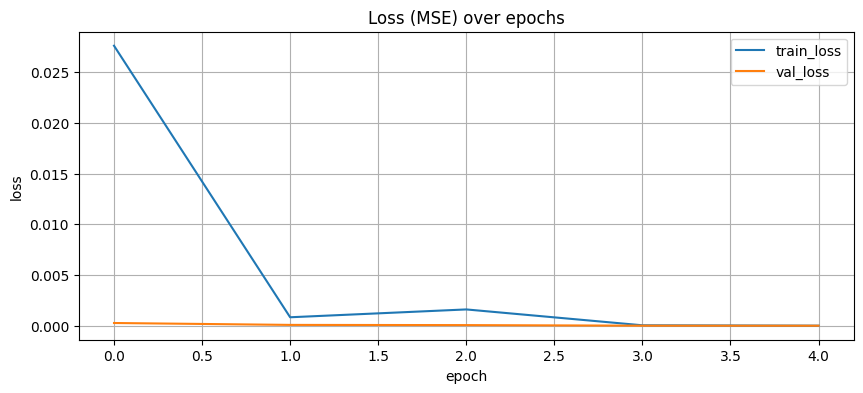

Final epoch metrics (last values):
  accuracy: 1.0
  loss: 8.531533239874989e-06
  val_accuracy: 1.0
  val_loss: 4.886370788881322e-06


In [27]:
# ---------- PLOT TRAINING METRICS CELL ----------
import os
import joblib
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

MODEL_DIR = "saved_models"             # adjust if you saved elsewhere
HISTORY_JOBLIB = Path(MODEL_DIR) / "training_history.joblib"
HISTORY_CSV = Path(MODEL_DIR) / "training_history.csv"
MANIFEST_PATH = Path(MODEL_DIR) / "pipeline_manifest_reg.joblib"

def load_history():
    """
    Tries multiple ways to locate training history:
    1) global variable named `history` (Keras History object)
    2) saved joblib at saved_models/training_history.joblib (dict)
    3) saved csv saved_models/training_history.csv
    4) as a last resort, check manifest for metrics (unlikely)
    Returns dict mapping metric -> list(values)
    """
    # 1) global history object
    if 'history' in globals():
        h = globals()['history']
        # If it's a Keras History object
        if hasattr(h, 'history'):
            print("Loaded: 'history' object from notebook globals.")
            return h.history
        # If it's already a dict
        if isinstance(h, dict):
            print("Loaded: 'history' (dict) from globals.")
            return h

    # 2) joblib
    if HISTORY_JOBLIB.exists():
        try:
            d = joblib.load(HISTORY_JOBLIB)
            if isinstance(d, dict):
                print(f"Loaded history from {HISTORY_JOBLIB}")
                return d
        except Exception as e:
            print("Failed to load joblib history:", e)

    # 3) csv
    if HISTORY_CSV.exists():
        try:
            import pandas as pd
            df = pd.read_csv(HISTORY_CSV)
            # convert dataframe columns to lists
            print(f"Loaded history from {HISTORY_CSV}")
            return {c: df[c].dropna().tolist() for c in df.columns}
        except Exception as e:
            print("Failed to load CSV history:", e)

    # 4) maybe saved in manifest (rare)
    if MANIFEST_PATH.exists():
        try:
            m = joblib.load(MANIFEST_PATH)
            # Some people might have saved metrics into manifest; check keys
            if isinstance(m, dict) and any(k in m for k in ('history','metrics','train_history')):
                for k in ('history','metrics','train_history'):
                    if k in m:
                        print(f"Loaded history from manifest key '{k}'")
                        return m[k]
        except Exception:
            pass

    # nothing found
    return None

hist = load_history()
if hist is None:
    raise RuntimeError(
        "No training history found.\n\n"
        "Options:\n"
        "1) If you still have the `history` variable in your notebook, name it `history` (the Keras History returned by model.fit) and re-run this cell.\n"
        "2) Re-run training with this line after model.fit(...):\n"
        "   joblib.dump(history.history, os.path.join(model_dir, 'training_history.joblib'))\n"
        "   (or save CSV similarly). Then re-run this plotting cell.\n"
    )

# hist should be a dict metric -> list
metrics = list(hist.keys())
print("Found metrics:", metrics)

# Helpful derived metrics
has_val_loss = 'val_loss' in hist
has_mse = 'mse' in hist or 'val_mse' in hist
has_mae = 'mae' in hist or 'val_mae' in hist

# convert to numpy arrays for plotting
def arr(k):
    return np.array(hist[k]) if k in hist else None

# Plot 1: Loss (train vs val if available)
plt.figure(figsize=(10,4))
plt.title("Loss (MSE) over epochs")
plt.plot(arr('loss'), label='train_loss')
if has_val_loss:
    plt.plot(arr('val_loss'), label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: MAE (if present)
if has_mae:
    plt.figure(figsize=(10,4))
    plt.title("MAE over epochs")
    if 'mae' in hist:
        plt.plot(arr('mae'), label='train_mae')
    if 'val_mae' in hist:
        plt.plot(arr('val_mae'), label='val_mae')
    plt.xlabel('epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot 3: RMSE if any MSE present
# Keras might have 'mse' or 'val_mse'; if present compute sqrt and plot
if has_mse:
    plt.figure(figsize=(10,4))
    plt.title("RMSE over epochs (derived from MSE)")
    if 'mse' in hist:
        plt.plot(np.sqrt(arr('mse')), label='train_rmse')
    if 'val_mse' in hist:
        plt.plot(np.sqrt(arr('val_mse')), label='val_rmse')
    plt.xlabel('epoch')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid(True)
    plt.show()

# Optional: show table of final metrics
finals = {k: (hist[k][-1] if isinstance(hist[k], (list,tuple)) and len(hist[k])>0 else hist[k]) for k in hist}
print("Final epoch metrics (last values):")
for k,v in finals.items():
    print(f"  {k}: {v}")
